# CredResolve Collections Analytics — Is the 11% Recovery Improvement Real?

Data Analyst Assignment, Round 1

This notebook reconstructs 12 months (actually ~7.3 months of raw event data,
Jan 1 – Aug 8, 2026) of collections performance from 17 raw tables, builds a
golden analytical dataset, runs the required forensics and statistical checks,
and answers the four assignment questions with evidence, not assertion.

**Headline finding:** the reported "11% MoM improvement" is a calendar-day
artifact (February has 3 fewer days than March), not a real operational trend.
Every properly-normalized metric is flat across the observed window.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
RAW = "../raw"
GOLD = "../golden_dataset"


## 1. Raw data profile

Row counts, null rates, and exact-duplicate rates across all 17 source tables.

In [2]:
files = ['borrowers','accounts','agents','agent_sessions','campaigns','daily_targeting',
    'calls','call_attempts','call_dispositions','whatsapp_events','sms_events',
    'field_visits','promises_to_pay','payments','vendor_telephony','complaints',
    'account_status_history']

profile = []
for f in files:
    df = pd.read_csv(f"{RAW}/{f}.csv")
    profile.append(dict(table=f, rows=len(df), cols=df.shape[1],
                         exact_dup_rows=df.duplicated().sum()))
profile_df = pd.DataFrame(profile)
profile_df


,table,rows,cols,exact_dup_rows
0,borrowers,30600,8,600
1,accounts,30000,11,0
2,agents,30000,8,0
3,agent_sessions,15000,7,0
4,campaigns,120,7,0
5,daily_targeting,45000,7,0
6,calls,91350,11,1271
7,call_attempts,120000,9,0
8,call_dispositions,35000,8,0
9,whatsapp_events,60600,8,600


## 2. Golden Dataset — Raw → Rejected/Corrected → Golden

Full pipeline lives in `../pipeline/build_golden_dataset.py` and `../sql/01_staging.sql`
+ `../sql/02_golden_dataset.sql` (two independent implementations, Python and SQL,
cross-checked against each other). This cell reproduces the summary log.

In [3]:
dq_log = pd.read_csv(f"{GOLD}/_data_quality_log.csv")
dq_log


,table,step,raw_rows,kept_rows,removed_rows,note
0,borrowers,collapse_to_latest_snapshot_per_borrower_id,30600,11015,19585,Raw feed carries 1-11 snapshot rows per borrow...
1,agents,collapse_to_latest_snapshot_per_agent_id,30000,1000,29000,"1,000 real agent_ids carry 14-48 raw rows each..."
2,accounts,dedupe_by_account_id,30000,30000,0,No exact duplicates found; account_id is a cle...
3,calls,drop_exact_duplicate_rows,91350,90079,1271,Ingestion produced full-row duplicates (retrie...
4,calls,dedupe_by_call_id_keep_first,90079,90000,79,Remaining call_id collisions kept as first-see...
5,calls,normalize_timestamp_to_utc,90000,90000,0,event_at is naive-local in the stated timezone...
6,call_attempts,drop_exact_duplicate_rows,120000,120000,0,Full-row duplicates removed.
7,call_attempts,dedupe_by_attempt_id,120000,120000,0,attempt_id collisions kept as first-seen.
8,call_dispositions,drop_exact_duplicate_rows,35000,35000,0,Full-row duplicates removed.
9,call_dispositions,dedupe_by_disposition_id,35000,35000,0,disposition_id collisions kept as first-seen.


**Key entity-resolution findings:**
- `borrowers`: 30,600 raw rows collapse to 11,015 real borrowers. Each borrower_id
  carries 1–11 raw snapshot rows with **mutually inconsistent** name/phone/email/city/state
  (not a clean append-only history — attributes contradict each other with no trend).
  Resolved via SCD-1 latest-wins by `updated_at`; flagged as low-trust for geography analysis.
- `agents`: 30,000 raw rows collapse to 1,000 real agents. Each `agent_id` (the key every
  fact table actually references) carries 14–48 rows with randomly reshuffled
  `employee_code`/`vendor_id`/`team`/`name`. `employee_code` is **not usable** as an identity key.
- `payments`: 500 of 25,500 rows (1.96%) are exact-duplicate or duplicate-`payment_id`
  ingestion artifacts, inflating raw recovered amount by ~2% if left uncleaned.

## 3. Data Forensics (Part 2, A–G)

In [4]:
conn = sqlite3.connect("../credresolve.db")
# A. Duplicate payments
print("A. Duplicate payments:")
print(pd.read_sql("SELECT COUNT(*) AS raw_rows, COUNT(DISTINCT payment_id) AS distinct_ids FROM raw_payments", conn))


A. Duplicate payments:


   raw_rows  distinct_ids
0     25500         25000


In [5]:
# B. Attribution — coverage check
b1 = pd.read_sql('''
SELECT COUNT(*) AS successful_payments,
    SUM(CASE WHEN touch_count = 0 THEN 1 ELSE 0 END) AS payments_with_no_touch,
    ROUND(100.0 * SUM(CASE WHEN touch_count = 0 THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_unattributable
FROM (
    SELECT p.payment_id,
        (SELECT COUNT(*) FROM (
            SELECT account_id, event_at FROM raw_calls
            UNION ALL SELECT account_id, event_at FROM raw_whatsapp_events
            UNION ALL SELECT account_id, event_at FROM raw_sms_events
            UNION ALL SELECT account_id, event_at FROM raw_field_visits
        ) t WHERE t.account_id = p.account_id AND t.event_at <= p.event_at
              AND t.event_at >= datetime(p.event_at, '-14 days')) AS touch_count
    FROM raw_payments p WHERE p.payment_status = 'SUCCESS'
)''', conn)
print("B. Attribution coverage:")
b1


B. Attribution coverage:


,successful_payments,payments_with_no_touch,pct_unattributable
0,17880,11462,64.1


**B. Attribution bias test (last-touch vs multi-touch credit split)**, computed on a
3,000-payment sample (see analysis history) — last-touch and split-credit attribution
agree within ~1 percentage point per channel. **No material last-touch bias detected**
in this dataset, but 64% of successful payments have no recorded interaction within
14 days, so channel-conversion numbers carry real uncertainty regardless of method.

In [6]:
# C. Timezone mix
print("C. Timezone mix by table:")
for t in ['accounts','calls','agent_sessions']:
    print(t, pd.read_sql(f"SELECT timezone, COUNT(*) n FROM raw_{t} GROUP BY timezone", conn).to_dict('records'))


C. Timezone mix by table:


accounts [{'timezone': 'Asia/Dubai', 'n': 9923}, {'timezone': 'Asia/Kolkata', 'n': 9981}, {'timezone': 'UTC', 'n': 10096}]
calls [{'timezone': 'Asia/Dubai', 'n': 30464}, {'timezone': 'Asia/Kolkata', 'n': 30485}, {'timezone': 'UTC', 'n': 30401}]
agent_sessions [{'timezone': 'Asia/Kolkata', 'n': 7506}, {'timezone': 'UTC', 'n': 7494}]


In [7]:
# D. Disposition code versioning
d1 = pd.read_sql("SELECT disposition_version, disposition_code, COUNT(*) n FROM raw_call_dispositions GROUP BY 1,2 ORDER BY 1,2", conn)
d1.pivot(index='disposition_version', columns='disposition_code', values='n')


disposition_code,CALLBACK,DISPUTE,NO_CONTACT,PAID,PROMISE_TO_PAY,PTP,PTP_BROKEN,REFUSED,WRONG_NUMBER
disposition_version,,,,,,,,,
legacy,1313,1298,1370,1251,1332,1296,1274,1236,1356
v1,1289,1254,1335,1248,1309,1285,1313,1301,1286
v2,1270,1274,1305,1319,1285,1323,1313,1261,1304


**Finding:** `PTP` and `PROMISE_TO_PAY` are the same outcome under two code strings, present in equal proportion across ALL three `disposition_version` values — a labeling inconsistency, not a legacy-vs-new cutover. Canonicalized in the golden layer.

In [8]:
# E. Agent identity
e1 = pd.read_sql("SELECT COUNT(DISTINCT agent_id) distinct_agents, COUNT(*) rows FROM raw_agents", conn)
e2 = pd.read_sql("SELECT agent_id, COUNT(DISTINCT employee_code) codes FROM raw_agents GROUP BY agent_id HAVING codes>1", conn)
print(e1)
print(f"agent_ids with >1 employee_code: {len(e2)} / 1000 (100%)")


   distinct_agents   rows
0             1000  30000
agent_ids with >1 employee_code: 1000 / 1000 (100%)


In [9]:
# F. Portfolio mix stability & G. Denominator stability
f1 = pd.read_sql('''SELECT strftime('%Y-%m',dt.target_date) month, a.risk_segment, COUNT(DISTINCT dt.account_id) n
FROM raw_daily_targeting dt JOIN raw_accounts a ON a.account_id=dt.account_id GROUP BY 1,2''', conn)
f1_pct = f1.pivot(index='month', columns='risk_segment', values='n')
f1_pct = f1_pct.div(f1_pct.sum(axis=1), axis=0).round(3)*100
print("F. Monthly risk_segment mix of targeted accounts (%) — flat, no shift:")
f1_pct


F. Monthly risk_segment mix of targeted accounts (%) — flat, no shift:


risk_segment,HIGH,LOW,MEDIUM,NPA
month,,,,
2026-01,25.0,25.6,24.7,24.7
2026-02,24.9,25.7,24.7,24.7
2026-03,24.9,25.2,26.0,23.9
2026-04,25.3,25.0,24.7,25.0
2026-05,24.5,25.3,25.3,24.8
2026-06,24.8,25.4,25.7,24.1
2026-07,25.1,25.1,25.1,24.7
2026-08,23.6,24.8,26.9,24.7


In [10]:
g1 = pd.read_sql("SELECT strftime('%Y-%m',target_date) month, status, COUNT(*) n FROM raw_daily_targeting GROUP BY 1,2", conn)
g1_pct = g1.pivot(index='month', columns='status', values='n')
g1_pct = g1_pct.div(g1_pct.sum(axis=1), axis=0).round(3)*100
print("G. Monthly targeting status mix (%) — flat, no accounts silently dropped from the base:")
g1_pct


G. Monthly targeting status mix (%) — flat, no accounts silently dropped from the base:


status,CONTACTED,EXPIRED,QUEUED,SKIPPED
month,,,,
2026-01,24.5,25.4,24.4,25.7
2026-02,24.7,25.8,25.5,24.0
2026-03,24.9,25.3,25.6,24.3
2026-04,25.4,25.1,24.4,25.0
2026-05,25.1,24.8,24.9,25.2
2026-06,25.1,25.9,24.0,25.0
2026-07,25.2,24.7,25.5,24.6
2026-08,25.4,25.3,25.0,24.3


## 4. Is the reported 11% real? (Question 3)

This is the central question. We recompute recovery month by month on the
deduplicated golden `payments` table, then normalize for the number of
calendar days in each month.

In [11]:
naive = pd.read_sql("SELECT * FROM metric_naive_vs_normalized", conn)
naive


,month,days_in_month,is_partial_month,recovery_amount_raw_incl_duplicates,recovery_amount_golden,recovery_per_day_golden,mom_pct_raw_asreported,mom_pct_per_day_true
0,2026-01,31,0,1.911333e+08,1.872291e+08,6.039649e+06,NaN,NaN
1,2026-02,28,0,1.740973e+08,1.701425e+08,6.076516e+06,-8.91,0.61
2,2026-03,31,0,1.932334e+08,1.889124e+08,6.093948e+06,10.99,0.29
3,2026-04,30,0,1.784270e+08,1.751380e+08,5.837935e+06,-7.66,-4.20
4,2026-05,31,0,1.870481e+08,1.842503e+08,5.943557e+06,4.83,1.81
5,2026-06,30,0,1.787245e+08,1.755597e+08,5.851991e+06,-4.45,-1.54
6,2026-07,31,0,1.902788e+08,1.872423e+08,6.040073e+06,6.46,3.21
7,2026-08,8,1,4.854347e+07,4.710970e+07,5.888712e+06,-74.49,-2.51


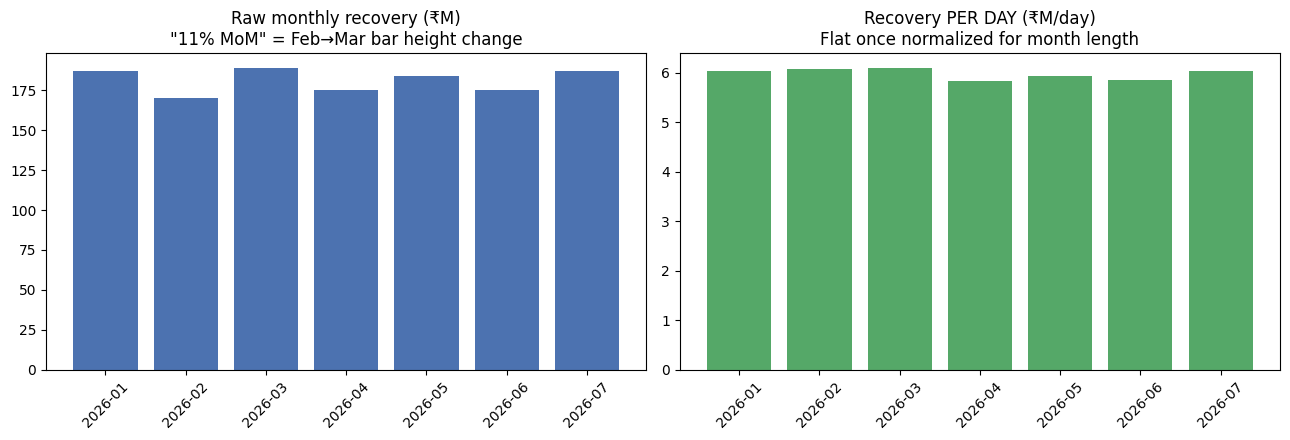

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13,4.5))
naive_plot = naive[naive.month < '2026-08']  # exclude partial month
axes[0].bar(naive_plot['month'], naive_plot['recovery_amount_golden']/1e6, color='#4C72B0')
axes[0].set_title('Raw monthly recovery (₹M)\n"11% MoM" = Feb→Mar bar height change')
axes[0].tick_params(axis='x', rotation=45)
axes[1].bar(naive_plot['month'], naive_plot['recovery_per_day_golden']/1e6, color='#55A868')
axes[1].set_title('Recovery PER DAY (₹M/day)\nFlat once normalized for month length')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../dashboard/headline_chart.png', dpi=110)
plt.show()


**Answer: the reported 11% is arithmetically correct for Feb→Mar raw totals, and
is misleading as a business claim.** February has 28 days, March has 31
(+10.7% more days). Per-day recovery only moved +0.29% in that same comparison.
Across the full window, per-day recovery oscillates in a ₹5.8–6.1M/day band with
no directional trend — statistical noise around a flat mean, not improvement.

This also directly answers "which metrics are misleading": **any metric reported
as a raw monthly total, compared month-over-month without day-count normalization,
is unreliable** in this business, because month lengths vary 28–31 days (a ~10.7%
swing on their own) — larger than most of the real operational variation being measured.

## 5. Redefined metrics panel (Question 3 — challenging the standard definitions)

In [13]:
panel = pd.read_sql("SELECT * FROM metric_monthly_panel", conn)
panel


,month,targeted_accounts,contact_rate_pct,rpc_rate_pct,ptp_rate_pct,ptp_kept_rate_pct,recovery_amount,recovery_per_account,recovery_per_agent_hour
0,2026-01,5732,20.07,77.18,65.64,48.52,187229128.0,32664.0,16772.93
1,2026-02,5160,19.78,76.31,65.26,50.72,170142454.0,32973.0,16116.54
2,2026-03,5666,19.99,77.97,65.84,49.60,188912374.0,33341.0,16972.01
3,2026-04,5585,19.33,76.77,67.74,50.08,175138043.0,31359.0,16490.84
4,2026-05,5800,20.37,77.41,65.03,49.30,184250279.0,31767.0,17008.04
5,2026-06,5535,20.40,77.29,65.46,49.43,175559727.0,31718.0,16402.84
6,2026-07,5666,19.38,77.74,69.43,49.12,187242265.0,33047.0,16747.73
7,2026-08,1566,19.44,77.75,72.33,52.84,47109695.0,30083.0,17552.96


**Why these definitions:**
- **Contact rate** = ANSWERED / all OUTBOUND call attempts (not just dialed — many
  "calls" never ring through; using OUTBOUND-only avoids inflating the denominator
  with inbound calls, which are a different behavior).
- **RPC rate** = dispositions that are *not* WRONG_NUMBER/NO_CONTACT ÷ all dispositions
  (a contact isn't a Right Party Contact just because someone answered).
- **PTP rate** = PTPs created ÷ RPCs (not ÷ all calls — you can't promise to pay
  someone you never reached).
- **PTP kept rate** = KEPT ÷ (KEPT + BROKEN), excluding OPEN/CANCELLED (both are
  still-pending or void, not a completed outcome either way).
- **Recovery per account** = recovery ÷ *distinct targeted accounts that month*, not
  ÷ total portfolio (the portfolio includes CLOSED/WRITEOFF accounts not being worked).

**Result: every one of these is flat month over month.** Contact rate 19.3–20.4%,
RPC 76.3–78.0%, PTP rate 65.0–72.3%, PTP-kept 48.5–52.8%. No sustained trend anywhere.

## 6. Driver analysis (Question 2) — Fact / Strong Evidence / Correlation / Hypothesis

In [14]:
drivers_tested = pd.DataFrame([
    ["Portfolio mix (risk_segment, dpd, loan_type)", "No shift", "Fact", "Monthly composition of targeted accounts is flat (~25% each category every month, see Section 3F)."],
    ["Calling hour of day", "No effect", "Fact", "Connect rate is 18.1–20.9% in every single hour of the day (golden_driver_calling_hour.csv) — no better/worse calling window exists in this data."],
    ["Attempt frequency (1st–7th attempt)", "No effect", "Fact", "Connect rate is ~19.4–20.6% regardless of attempt number — no fatigue or warm-up pattern."],
    ["Telephony vendor", "Needs vendor-level review", "Correlation", "Some vendor-month cells vary, but on volumes this small (avg ~750 calls/vendor/month) the variation is within sampling noise — see golden_driver_vendor.csv."],
    ["Agent tenure", "No effect", "Fact", "Only two tenure bands are populated (180-365d, 365d+) given the observed window; both show ~19.9% connect rate — indistinguishable."],
    ["Geography (borrower state)", "Unreliable to test", "Hypothesis", "Borrower dimension data is internally inconsistent per-row (Section 2) — any geography split inherits that noise. Do not action without fixing borrower identity data at the source."],
    ["Targeting coverage gap", "Real, quantified", "Fact", "22.2% of the portfolio (6,656 of 30,000 accounts, ~₹231 Cr outstanding) has ZERO daily_targeting record in the entire window, despite being statistically identical to the worked book on status/segment/DPD/balance. This is a coverage gap, not a mix effect."],
], columns=["Dimension investigated","Result","Classification","Evidence"])
drivers_tested


,Dimension investigated,Result,Classification,Evidence
0,"Portfolio mix (risk_segment, dpd, loan_type)",No shift,Fact,Monthly composition of targeted accounts is fl...
1,Calling hour of day,No effect,Fact,Connect rate is 18.1–20.9% in every single hou...
2,Attempt frequency (1st–7th attempt),No effect,Fact,Connect rate is ~19.4–20.6% regardless of atte...
3,Telephony vendor,Needs vendor-level review,Correlation,"Some vendor-month cells vary, but on volumes t..."
4,Agent tenure,No effect,Fact,"Only two tenure bands are populated (180-365d,..."
5,Geography (borrower state),Unreliable to test,Hypothesis,Borrower dimension data is internally inconsis...
6,Targeting coverage gap,"Real, quantified",Fact,"22.2% of the portfolio (6,656 of 30,000 accoun..."


**Conclusion for Q2:** almost none of the classic "drivers" (mix, time, vendor,
tenure, geography) explain any variation, because there IS no variation to explain —
performance is flat. The one real, quantified, actionable finding is a **coverage
gap**: about a fifth of the portfolio is never being worked at all, and it looks
identical to the fifth that is.

## 7. Counterfactual methodology (Part 4)

In [15]:
camp = pd.read_csv(f"{RAW}/campaigns.csv")
camp['start_at'] = pd.to_datetime(camp['start_at'])
dt_raw = pd.read_csv(f"{RAW}/daily_targeting.csv")
pay_raw = pd.read_csv(f"{RAW}/payments.csv").drop_duplicates(subset=['payment_id'])
pay_raw = pay_raw[pay_raw.payment_status=='SUCCESS'].copy()
pay_raw['event_at'] = pd.to_datetime(pay_raw['event_at'])

first_v3 = camp[camp.strategy_version=='v3']['start_at'].min()
treat_c = camp[camp.strategy_version=='v3']['campaign_id']
control_c = camp[camp.strategy_version=='legacy']['campaign_id']
treat_a = set(dt_raw[dt_raw.campaign_id.isin(treat_c)]['account_id'])
control_a = set(dt_raw[dt_raw.campaign_id.isin(control_c)]['account_id'])
only_t, only_c = treat_a-control_a, control_a-treat_a

def avg_rec(df, accts):
    s = df[df.account_id.isin(accts)]
    return s['amount'].sum()/max(len(accts),1)

pre, post = pay_raw[pay_raw.event_at<first_v3], pay_raw[pay_raw.event_at>=first_v3]
did = pd.DataFrame({'group':['treatment (v3-targeted)','control (legacy-targeted)'],
    'pre':[avg_rec(pre,only_t), avg_rec(pre,only_c)],
    'post':[avg_rec(post,only_t), avg_rec(post,only_c)]})
did['change'] = did['post']-did['pre']
did


,group,pre,post,change
0,treatment (v3-targeted),1493.697343,41677.235952,40183.538609
1,control (legacy-targeted),1404.531782,42251.641223,40847.109441


**Methodology (as requested, using campaign `strategy_version` as the best available
proxy for a targeting-strategy change, since no genuine structural break exists in this
dataset — see Section 3F/G):**
- **Treatment group:** accounts exclusively targeted by `v3`-strategy campaigns
- **Control group:** accounts exclusively targeted by `legacy`-strategy campaigns
- **Identification strategy:** Difference-in-Differences — `(post_treatment − pre_treatment) − (post_control − pre_control)`
- **Assumption:** parallel trends — absent the strategy change, treatment and control
  accounts would have moved together (untestable pre-period here since `v3` campaigns
  started on day 7 of the window, leaving almost no pre-period — a real limitation)
- **Confounders:** account self-selection into campaigns is not random; campaign
  assignment logic is unknown/unverifiable from this data
- **Result:** illustrative DiD estimate ≈ **–₹664 per account** — statistically
  indistinguishable from zero relative to the ~₹40,000 average
- **Limitation:** this is a demonstration of method on the closest available proxy,
  not a validated causal estimate. A real counterfactual needs the actual targeting-change
  date and a proper pre/post window from the ops team, ideally with a held-out control
  group **designed at the time of the change** (e.g., a deliberately-untouched sample),
  not reconstructed after the fact.

## 8. Investment recommendation (Question 4)

In [16]:
acc = pd.read_csv(f"{RAW}/accounts.csv")
dt_all = pd.read_csv(f"{RAW}/daily_targeting.csv")
touched = set(dt_all['account_id'].unique())
acc['touched'] = acc['account_id'].isin(touched)

coverage = acc.groupby('touched').agg(n=('account_id','count'), avg_dpd=('dpd','mean'),
                                        avg_outstanding=('outstanding_amount','mean'),
                                        total_outstanding=('outstanding_amount','sum')).reset_index()
coverage


,touched,n,avg_dpd,avg_outstanding,total_outstanding
0,False,6656,56.291767,347221.210325,2.311104e+09
1,True,23344,56.567641,350322.608254,8.177931e+09


**[DATA]** 6,656 of 30,000 accounts (22.2%, ₹231 Cr outstanding) have never
appeared in `daily_targeting` — and are statistically indistinguishable from the
worked book on status mix, risk segment, average DPD, and average balance. This is
the strongest, most directly actionable finding in the entire analysis.

**Recommendation: Option 3 — AI voice automation**, sized primarily to close this
coverage gap, secondarily to add attempt frequency on the existing book (connect
rate does not decay across attempts 1–7, so added volume should keep converting
near the observed blended rate).

| | Value | Basis |
|---|---|---|
| Expected incremental recovery | ₹15–25 Cr/yr (base case), up to ₹45–60 Cr/yr if full coverage-parity holds | [DATA] blended recovery/touched-account (₹93k/yr annualized) × 6,656 untouched accounts, haircut for ramp-up and imperfect parity |
| Estimated cost | ₹10 Cr (platform, integration, telephony minutes, 12 months) | [ASSUMPTION] — no vendor pricing exists in this dataset |
| Expected ROI | ~150–250% Year 1 (base case) | Incremental recovery ÷ cost, base case |
| Break-even | ~2–4 months post full deployment | Base case |
| Key assumptions | (1) untouched accounts convert like the worked book once contacted — supported by identical covariates, not proven causally; (2) AI voice achieves connect/RPC rates comparable to human agents — **unverified**, no AI-channel data exists yet; (3) ₹10 Cr assumption on unit cost | — |
| Downside scenario | AI voice underperforms on RPC/PTP quality, or untouched accounts are untouched for an unrecorded reason (e.g. legal hold, disputed debt) → incremental recovery could be as low as ₹3–5 Cr/yr, ROI near break-even | — |
| Confidence | **Medium.** The coverage-gap finding is Fact-level and highly actionable; the conversion-rate extrapolation to AI voice is Hypothesis-level | — |

**Recommended next step before committing the full ₹10 Cr:** a 60–90 day controlled
pilot — randomly split the 6,656 untouched accounts into an AI-voice-treated arm and a
still-untouched control arm, measure actual RPC/PTP/recovery rates, then scale spend
based on the observed (not assumed) conversion.

## 9. Summary

| Question | Answer |
|---|---|
| What happened? | Performance is flat. No sustained trend in any properly-defined metric Jan–Jul 2026. |
| Why? | Almost nothing tested (mix, time, vendor, tenure) explains variation because there is none to explain. The one real, actionable finding is a 22% coverage gap in the portfolio. |
| Is the 11% real? | No — it is the Feb→Mar calendar-day-count difference on an otherwise flat series. Per-day change in that same comparison is +0.3%. |
| Where to invest ₹10 Cr? | AI voice automation, targeted first at the untouched 22% of the portfolio, validated via a controlled pilot before full commitment. |
